### How many trials?
Edit the numbers marked `👈` and re-run.

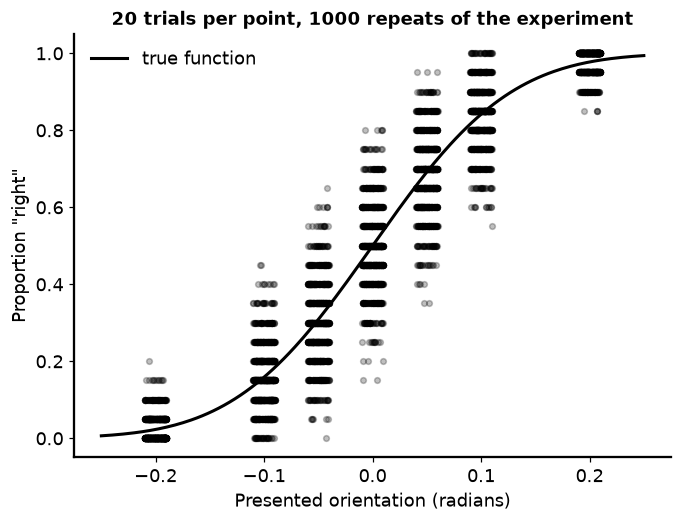

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

signal_strengths = np.array([-0.2,-0.1,-0.05,0,0.05,0.1,0.2])
noise_sd = 0.1
ntrials  = 20      # 👈 trials per signal strength -- try 5, 50, 200
nsim     = 1000    # repeat the whole experiment this many times
criterion = 0

rng = np.random.default_rng()
samples = rng.standard_normal((ntrials, signal_strengths.size, nsim)) * noise_sd \
          + signal_strengths[None, :, None]
proportion_right = (samples > criterion).mean(axis=0)        # (nsignals, nsim)

# jitter x a little so the cloud is visible
xj = signal_strengths[:, None] + rng.uniform(-0.01, 0.01, (signal_strengths.size, nsim))

fig, ax = plt.subplots(figsize=(7, 5))
xs = np.linspace(-0.25, 0.25, 200)
ax.plot(xs, norm.cdf(xs, 0, noise_sd), "k", lw=2, label="true function")
ax.scatter(xj.ravel(), proportion_right.ravel(), 14, color="k", alpha=0.25)
ax.set(xlabel="Presented orientation (radians)", ylabel='Proportion "right"',
       title=f"{ntrials} trials per point, {nsim} repeats of the experiment")
ax.legend()
plt.show()
